### Testing script of the CNN model
#### TODO:

+ Check how to improve the adaptive one so we can get similar scores
+ Make sure to save the other options still!!
+ Data Augmentation options!!

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


### **Notes to the output and the version meanings**
#### /cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
+ _wo_normalization: There we did not normalize the img in Load_Cifar with std and dev
+ v1: without data augmentation

Simple CNN
Total Training Time  : 338.53s
Total Validation Time: 43.40s

SimpleAdaptiveCNN
Total Training Time  : 338.12s
Total Validation Time: 42.64s


+ v2: with data augmentation

Simple CNN
Total Training Time  : 417.16s
Total Validation Time: 50.60s

SimpleAdaptiveCNN
Total Training Time  : 454.24s
Total Validation Time: 51.46s


#### /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
+ no suffix: without data augmentation

Simple CNN
Total Training Time  : 663.27s
Total Validation Time: 78.77s

SimpleAdaptiveCNN
Total Training Time  : 626.09s
Total Validation Time: 77.79s


+ v1: with data augmentation

Simple CNN
Total Training Time  : 615.57s
Total Validation Time: 71.32s

SimpleAdaptiveCNN
Total Training Time  : 747.35s
Total Validation Time: 83.39s


#### /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
+ no suffix: without data augmentation

Simple CNN
Total Training Time  : 711.45s
Total Validation Time: 85.77s

SimpleAdaptiveCNN
Total Training Time  : 638.99s
Total Validation Time: 75.98s


+ v1: with data augmentation

Simple CNN
Total Training Time  : 714.55s
Total Validation Time: 82.98s

SimpleAdaptiveCNN
Total Training Time  : 856.05s
Total Validation Time: 99.30s

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model

# https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision.transforms as transforms
from torchvision.transforms import v2


# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

# Create datasets
train_dataset = CIFAR10(split="train", transform=train_transforms)
test_dataset  = CIFAR10(split="test", transform=val_transforms)

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu
Train samples: 50000
Test samples: 10000


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")
/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


Training model: SimpleCNN
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/25


Train Loss: 1.7067 | Train Acc: 0.3704
Train Time: 42.38s
Val   Loss: 1.2698 | Val   Acc: 0.5364
Val   Time: 4.39s

Epoch 2/25


Train Loss: 1.3531 | Train Acc: 0.5145
Train Time: 38.44s
Val   Loss: 1.0864 | Val   Acc: 0.6118
Val   Time: 4.20s

Epoch 3/25


Train Loss: 1.1757 | Train Acc: 0.5850
Train Time: 38.93s
Val   Loss: 0.9713 | Val   Acc: 0.6497
Val   Time: 4.39s

Epoch 4/25


Train Loss: 1.0680 | Train Acc: 0.6208
Train Time: 39.33s
Val   Loss: 0.8925 | Val   Acc: 0.6852
Val   Time: 4.34s

Epoch 5/25


...

Train Loss: 0.6607 | Train Acc: 0.7725
Train Time: 34.48s
Val   Loss: 0.6221 | Val   Acc: 0.7913
Val   Time: 3.68s

Epoch 22/25


Train Loss: 0.6486 | Train Acc: 0.7805
Train Time: 34.87s
Val   Loss: 0.6070 | Val   Acc: 0.7908
Val   Time: 3.71s

Epoch 23/25


Train Loss: 0.6392 | Train Acc: 0.7810
Train Time: 35.23s
Val   Loss: 0.5857 | Val   Acc: 0.8023
Val   Time: 3.87s

Epoch 24/25


Train Loss: 0.6329 | Train Acc: 0.7838
Train Time: 34.66s
Val   Loss: 0.5533 | Val   Acc: 0.8113
Val   Time: 3.66s

Epoch 25/25


Train Loss: 0.6249 | Train Acc: 0.7847
Train Time: 34.44s
Val   Loss: 0.5658 | Val   Acc: 0.8104
Val   Time: 3.69s

Total Training Time  : 942.12s
Total Validation Time: 102.72s


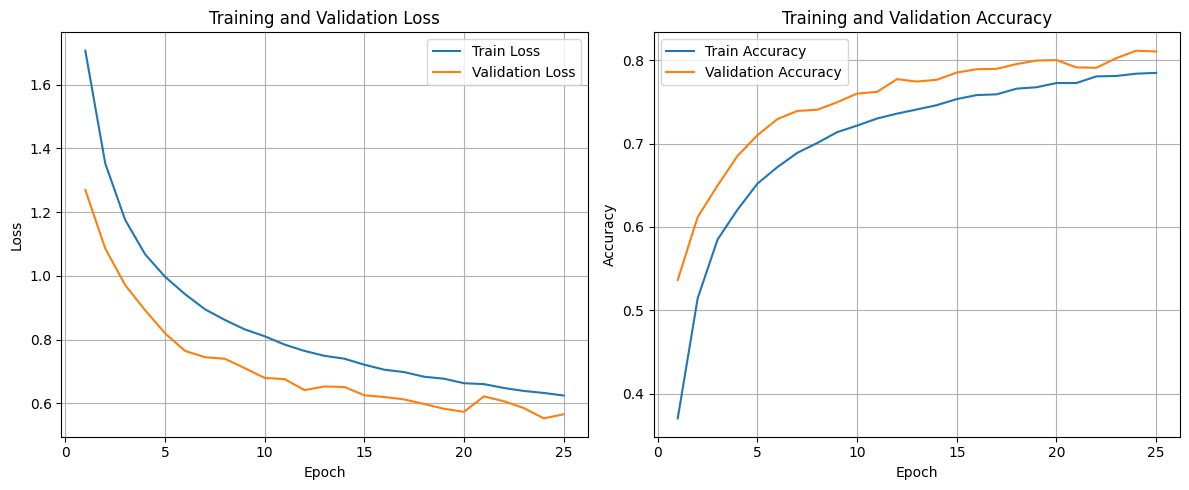

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_cifar10_v1.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.8104

Model Evaluation
----------------
Overall accuracy: 0.8104

Per-class accuracy:
  airplane: 0.881
automobile: 0.906
      bird: 0.721
       cat: 0.633
      deer: 0.735
       dog: 0.701
      frog: 0.881
     horse: 0.855
      ship: 0.890
     truck: 0.901

Classification report:
              precision    recall  f1-score   support

    airplane      0.745     0.881     0.808      1000
  automobile      0.926     0.906     0.916      1000
        bird      0.751     0.721     0.736      1000
         cat      0.660     0.633     0.646      1000
        deer      0.849     0.735     0.788      1000
         dog      0.772     0.701     0.735      1000
        frog      0.843     0.881     0.862      1000
       horse      0.836     0.855     0.845      1000
        ship      0.886     0.890     0.888      1000
      

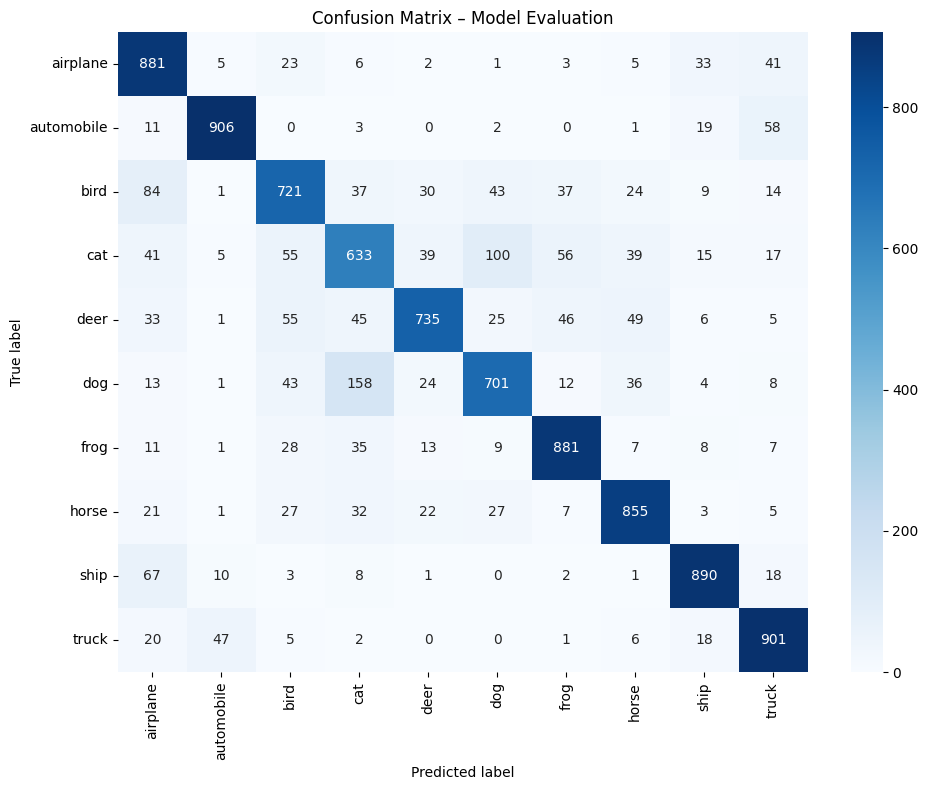

Training model: SimpleAdaptiveCNN
SimpleAdaptiveCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/25


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.8816 | Train Acc: 0.2863
Train Time: 33.90s
Val   Loss: 1.6198 | Val   Acc: 0.3921
Val   Time: 3.61s

Epoch 2/25


Train Loss: 1.5588 | Train Acc: 0.4193
Train Time: 33.69s
Val   Loss: 1.4604 | Val   Acc: 0.4637
Val   Time: 3.62s

Epoch 3/25


Train Loss: 1.3779 | Train Acc: 0.4955
Train Time: 33.84s
Val   Loss: 1.2657 | Val   Acc: 0.5268
Val   Time: 3.64s

Epoch 4/25


...

Train Loss: 0.6960 | Train Acc: 0.7596
Train Time: 33.80s
Val   Loss: 0.6793 | Val   Acc: 0.7624
Val   Time: 3.70s

Epoch 22/25


Train Loss: 0.6826 | Train Acc: 0.7641
Train Time: 33.72s
Val   Loss: 0.6625 | Val   Acc: 0.7699
Val   Time: 3.73s

Epoch 23/25


Train Loss: 0.6754 | Train Acc: 0.7669
Train Time: 33.95s
Val   Loss: 0.6994 | Val   Acc: 0.7566
Val   Time: 3.71s

Epoch 24/25


Train Loss: 0.6637 | Train Acc: 0.7709
Train Time: 33.84s
Val   Loss: 0.6466 | Val   Acc: 0.7753
Val   Time: 3.87s

Epoch 25/25


Train Loss: 0.6581 | Train Acc: 0.7754
Train Time: 33.68s
Val   Loss: 0.6814 | Val   Acc: 0.7617
Val   Time: 3.69s

Total Training Time  : 845.66s
Total Validation Time: 93.81s


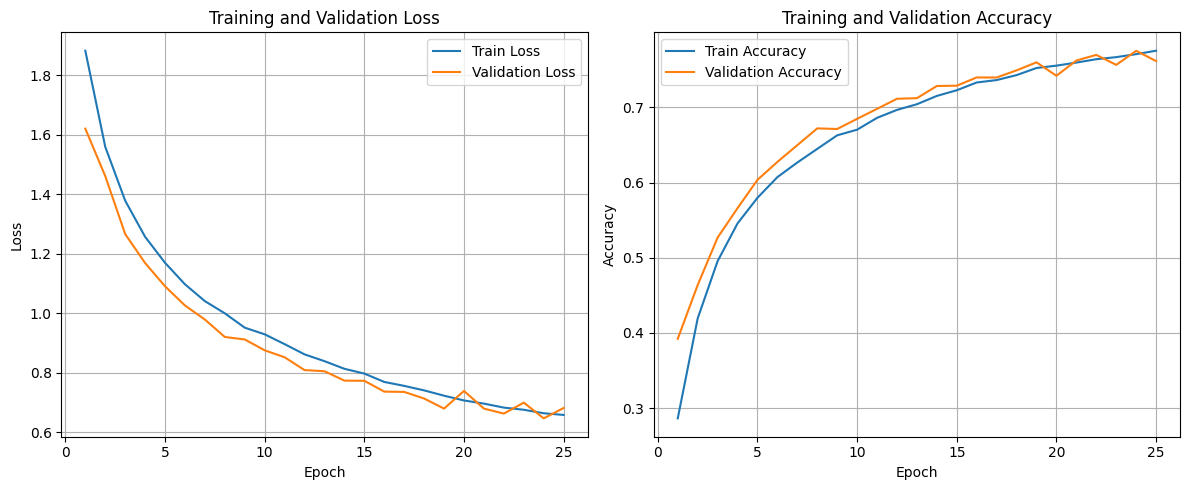

Training completed.
Saved trained model to: cnn_trained_models/simpleadaptivecnn_cifar10_v1.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.7617

Model Evaluation
----------------
Overall accuracy: 0.7617

Per-class accuracy:
  airplane: 0.906
automobile: 0.942
      bird: 0.648
       cat: 0.521
      deer: 0.737
       dog: 0.578
      frog: 0.878
     horse: 0.852
      ship: 0.821
     truck: 0.734

Classification report:
              precision    recall  f1-score   support

    airplane      0.674     0.906     0.773      1000
  automobile      0.806     0.942     0.869      1000
        bird      0.701     0.648     0.674      1000
         cat      0.686     0.521     0.592      1000
        deer      0.710     0.737     0.723      1000
         dog      0.793     0.578     0.669      1000
        frog      0.730     0.878     0.797      1000
       horse      0.743     0.852     0.794      1000
        ship      0.914     0.821     0.865      100

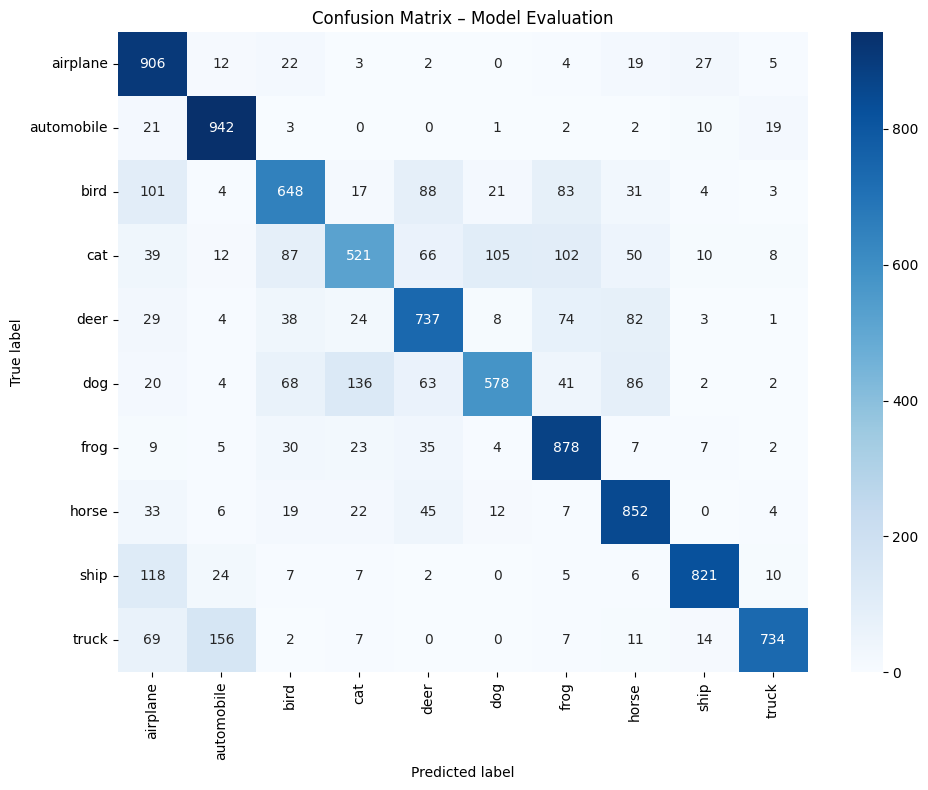

In [30]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2
epochs=25

model_selection = {"SimpleCNN": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier), 
                    "SimpleAdaptiveCNN": SimpleAdaptiveCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier)
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

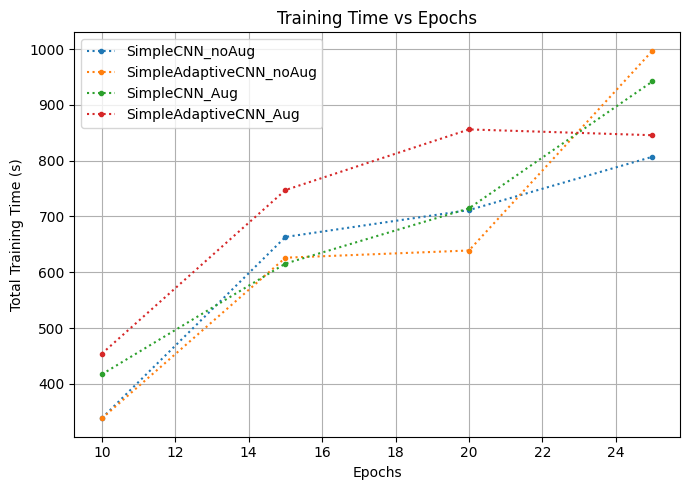

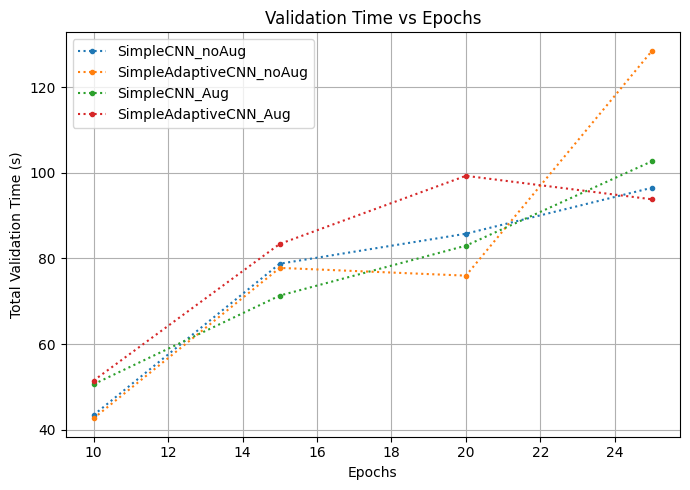

In [32]:
import matplotlib.pyplot as plt

train_val_times = {   
    #/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
    "SimpleCNN_10Epochs_noAug": {
        "Total Training Time": 338.53 ,
        "Total Validation Time": 43.4 
        } ,
    "SimpleAdaptiveCNN_10Epochs_noAug":{
        "Total Training Time"  : 338.12 ,
        "Total Validation Time": 42.64
        },
    "SimpleCNN_10Epochs_Aug": {
        "Total Training Time"  : 417.16,
        "Total Validation Time": 50.60
        },
    "SimpleAdaptiveCNN_10Epochs_Aug" : {
        "Total Training Time" : 454.24,
        "Total Validation Time": 51.46,
        },

    # /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
    "SimpleCNN_15Epochs_noAug": {
        "Total Training Time"  : 663.27,
        "Total Validation Time": 78.77
        },
    "SimpleAdaptiveCNN_15Epochs_noAug": {
        "Total Training Time"  : 626.09,
        "Total Validation Time": 77.79
        },
    "SimpleCNN_15Epochs_Aug": {
        "Total Training Time"  : 615.57,
        "Total Validation Time": 71.32
        },
    "SimpleAdaptiveCNN_15Epochs_Aug": {
        "Total Training Time"  : 747.35,
        "Total Validation Time": 83.39
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
    "SimpleCNN_20Epochs_noAug": {
        "Total Training Time"  : 711.45,
        "Total Validation Time": 85.77
        },
    "SimpleAdaptiveCNN_20Epochs_noAug": {
        "Total Training Time"  : 638.99,
        "Total Validation Time": 75.98
        },

    "SimpleCNN_20Epochs_Aug": {
        "Total Training Time"  : 714.55,
        "Total Validation Time": 82.98
        },
    "SimpleAdaptiveCNN_20Epochs_Aug": {
        "Total Training Time"  : 856.05,
        "Total Validation Time": 99.3
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
    "SimpleCNN_25Epochs_noAug":{
        "Total Training Time"  : 807.0,
        "Total Validation Time": 96.52
    },
    "SimpleAdaptiveCNN_25Epochs_noAug": {
        "Total Training Time"  : 997.14,
        "Total Validation Time": 128.53
    },

    "SimpleCNN_25Epochs_Aug": {
        "Total Training Time"  : 942.12,
        "Total Validation Time": 102.72
        },

    "SimpleAdaptiveCNN_25Epochs_Aug": {
        "Total Training Time"  : 845.66,
        "Total Validation Time": 93.81
        }
}


# Epochs
epochs = [10, 15, 20, 25]

# Extracted data in order of epochs above
train_times = {
    "SimpleCNN_noAug": [338.53, 663.27, 711.45, 807.0],
    "SimpleAdaptiveCNN_noAug": [338.12, 626.09, 638.99, 997.14],
    "SimpleCNN_Aug": [417.16, 615.57, 714.55, 942.12],
    "SimpleAdaptiveCNN_Aug": [454.24, 747.35, 856.05, 845.66],
}

val_times = {
    "SimpleCNN_noAug": [43.4, 78.77, 85.77, 96.52],
    "SimpleAdaptiveCNN_noAug": [42.64, 77.79, 75.98, 128.53],
    "SimpleCNN_Aug": [50.60, 71.32, 82.98, 102.72],
    "SimpleAdaptiveCNN_Aug": [51.46, 83.39, 99.3, 93.81],
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Class names from the dataset
classes = train_dataset.classes

def unnormalize(img_tensor):
    # Convert normalized tensor back to image for display
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_augmented_vs_original(transform, dataset, num_images=8):
    # Get original images (PIL) from dataset
    original_images = [dataset[i][0] for i in range(num_images)]

    # Apply augmentations
    augmented_images = [transform(img) for img in original_images]

    fig, axs = plt.subplots(2, num_images, figsize=(16, 4))
    fig.suptitle('Original Images (Top) vs. Augmented Images (Bottom)', fontsize=16)

    for i in range(num_images):
        # Display original images
        axs[0, i].imshow(original_images[i])
        axs[0, i].axis('off')
        if i == 0:
            axs[0, i].set_ylabel('Original', fontsize=12)

        # Display augmented images (unnormalized tensor)
        img = unnormalize(augmented_images[i])
        axs[1, i].imshow(img)
        axs[1, i].axis('off')
        if i == 0:
            axs[1, i].set_ylabel('Augmented', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# To use this function, pass your transform pipeline and the raw dataset without transforms:
show_augmented_vs_original(transform=train_transforms, dataset=raw_dataset)

### Old testing area


In [ ]:
trained_model = train_model(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10
)


Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 391/391 [00:33<00:00, 12.43it/s]

In [ ]:
# save the trained model
file_name = "cnn_trained_models/simple_cnn_cifar10_v2.pth"
torch.save(trained_model.state_dict(), file_name)
#del trained_model

In [8]:
# load the saved model with the same parameters initially set
trained_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32, base_channels=32, channel_multiplier=2)
trained_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [9]:
trained_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"Final validation accuracy: {correct / total:.4f}")


Final validation accuracy: 0.7299


In [10]:
from analysis.evaluation import evaluate_model

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Model Evaluation
----------------
Overall accuracy: 0.7299

Per-class accuracy:
  airplane: 0.861
automobile: 0.890
      bird: 0.627
       cat: 0.534
      deer: 0.649
       dog: 0.521
      frog: 0.822
     horse: 0.799
      ship: 0.852
     truck: 0.744

Classification report:
              precision    recall  f1-score   support

    airplane      0.643     0.861     0.736      1000
  automobile      0.807     0.890     0.846      1000
        bird      0.637     0.627     0.632      1000
         cat      0.554     0.534     0.544      1000
        deer      0.720     0.649     0.682      1000
         dog      0.719     0.521     0.604      1000
        frog      0.800     0.822     0.811      1000
       horse      0.757     0.799     0.778      1000
        ship      0.824     0.852     0.838      1000
       truck      0.859     0.744     0.797      1000

    accuracy                          0.730     10000
   macro avg      0.732     0.730     0.727     10000
weighted av

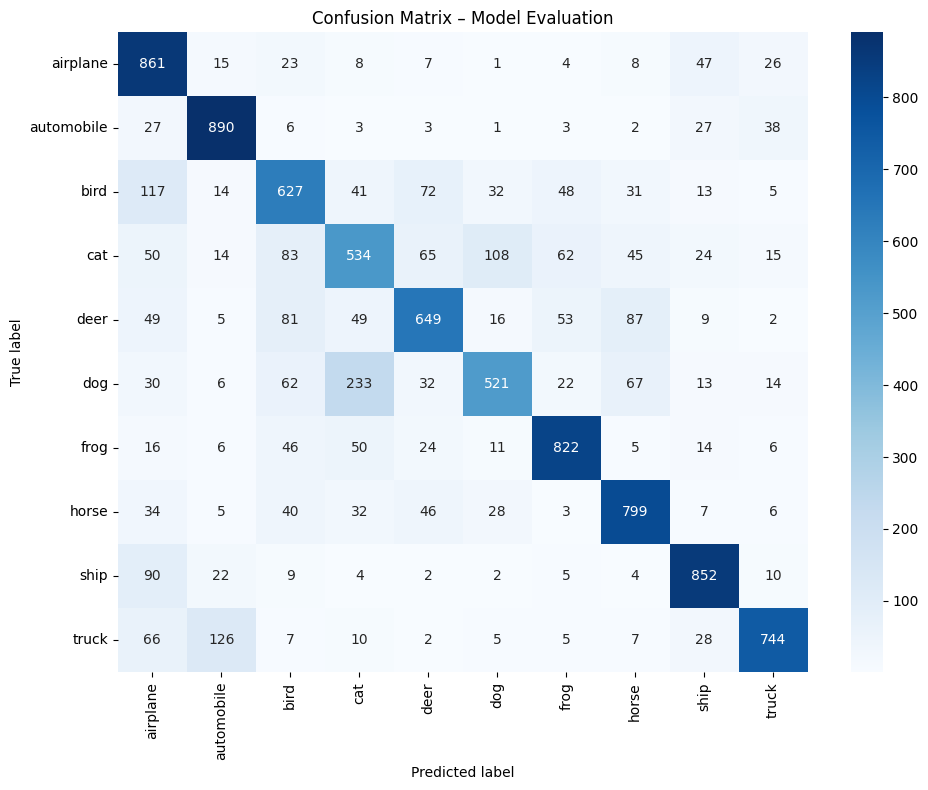

{'overall_accuracy': 0.7299000024795532,
 'per_class_accuracy': array([0.861, 0.89 , 0.627, 0.534, 0.649, 0.521, 0.822, 0.799, 0.852,
        0.744]),
 'confusion_matrix': array([[861,  15,  23,   8,   7,   1,   4,   8,  47,  26],
        [ 27, 890,   6,   3,   3,   1,   3,   2,  27,  38],
        [117,  14, 627,  41,  72,  32,  48,  31,  13,   5],
        [ 50,  14,  83, 534,  65, 108,  62,  45,  24,  15],
        [ 49,   5,  81,  49, 649,  16,  53,  87,   9,   2],
        [ 30,   6,  62, 233,  32, 521,  22,  67,  13,  14],
        [ 16,   6,  46,  50,  24,  11, 822,   5,  14,   6],
        [ 34,   5,  40,  32,  46,  28,   3, 799,   7,   6],
        [ 90,  22,   9,   4,   2,   2,   5,   4, 852,  10],
        [ 66, 126,   7,  10,   2,   5,   5,   7,  28, 744]]),
 'predictions': tensor([3, 8, 8,  ..., 5, 4, 7]),
 'labels': tensor([3, 8, 8,  ..., 5, 1, 7])}

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
evaluate_model(trained_model, valloader, device="cpu", class_names=class_names)

In [21]:
# target output size of 5x7
m = nn.AdaptiveAvgPool2d((5, 7))
input = torch.randn(1, 64, 8, 9)
output = m(input)
print(output.shape)

# target output size of 7x7 (square)
m = nn.AdaptiveAvgPool2d(7)
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 10x7
m = nn.AdaptiveAvgPool2d((None, 7))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 15x15
m = nn.AdaptiveAvgPool2d((15, 15))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of the same size
m = nn.AdaptiveAvgPool2d((2,2))
input = torch.randn(1, 6, 2, 2)
output = m(input)
print(output.shape)


torch.Size([1, 64, 5, 7])
torch.Size([1, 64, 7, 7])
torch.Size([1, 64, 10, 7])
torch.Size([1, 64, 15, 15])
torch.Size([1, 6, 2, 2])


In [23]:
input , output

(tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]),
 tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]))